# Emotion Text Classifier
### Comparing models for emotion classification: Logistic Regression vs Naive Bayes

This notebook reuses the same preprocessing and feature extraction pipeline defined in the baseline experiment to ensure a fair comparison between models.

### Objective

The goal of this notebook is to compare different models for emotion classification using the same preprocessing and feature extraction pipeline.

We focus on a fair comparison between Logistic Regression and Multinomial Naive Bayes.

## Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from src.data_loader import load_datasets
from src.preprocessing import add_clean_text_column
from src.features import split_features_labels, vectorize_datasets
from src.models.logistic_regression import train_logistic_regression
from src.models.naive_bayes import train_naive_bayes

## 1. Load Dataset

In [2]:
DATA_PATH = Path("../data/raw/emotion_dataset")

train_df, val_df, _ = load_datasets(DATA_PATH)

## 2. Text Preprocessing
#### We clean and normalize the text data by lowercasing and removing non-alphabetic characters

In [3]:
train_df = add_clean_text_column(train_df)
val_df = add_clean_text_column(val_df)

## Define Features and Labels

In [4]:
X_train, y_train = split_features_labels(train_df)
X_val, y_val = split_features_labels(val_df)

## 3. Feature Extraction with TF-IDF
#### We convert the cleaned text into numerical feature vectors using TF-IDF

In [5]:
X_train, X_val, _, vectorizer = vectorize_datasets(X_train, X_val, X_val)

## 4. Model Training
#### We train both Logistic Regression and Multinomial Naive Bayes using the same TF-IDF features

### Logistic Regression

In [6]:
lr_model = train_logistic_regression(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


### Naive Bayes

In [7]:
nb_model = train_naive_bayes(X_train, y_train)
print("Naive Bayes trained successfully.")

Naive Bayes trained successfully.


In [8]:
y_val_pred_lr = lr_model.predict(X_val)
y_val_pred_nb = nb_model.predict(X_val)

## 5. Model Evaluation
#### We evaluate both models on the validation set using accuracy and classification metrics

### Logistic Regression

In [9]:
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_val_pred_lr))
print("\nClassification Report (LR):\n")
print(classification_report(y_val, y_val_pred_lr))

Logistic Regression Accuracy: 0.8595

Classification Report (LR):

              precision    recall  f1-score   support

       anger       0.91      0.81      0.86       275
        fear       0.86      0.73      0.79       212
         joy       0.84      0.95      0.89       704
        love       0.88      0.62      0.73       178
     sadness       0.86      0.94      0.90       550
    surprise       0.85      0.58      0.69        81

    accuracy                           0.86      2000
   macro avg       0.87      0.77      0.81      2000
weighted avg       0.86      0.86      0.85      2000



### Naive Bayes

In [10]:
print("Naive Bayes Accuracy:", accuracy_score(y_val, y_val_pred_nb))
print("\nClassification Report (NB):\n")
print(classification_report(y_val, y_val_pred_nb, zero_division=0))

Naive Bayes Accuracy: 0.641

Classification Report (NB):

              precision    recall  f1-score   support

       anger       0.96      0.17      0.29       275
        fear       0.94      0.16      0.27       212
         joy       0.60      0.98      0.75       704
        love       1.00      0.03      0.05       178
     sadness       0.66      0.92      0.77       550
    surprise       0.00      0.00      0.00        81

    accuracy                           0.64      2000
   macro avg       0.69      0.38      0.35      2000
weighted avg       0.71      0.64      0.55      2000



## Confusion Matrix
#### The confusion matrix shows correct predictions and common misclassifications

### Logistic Regression

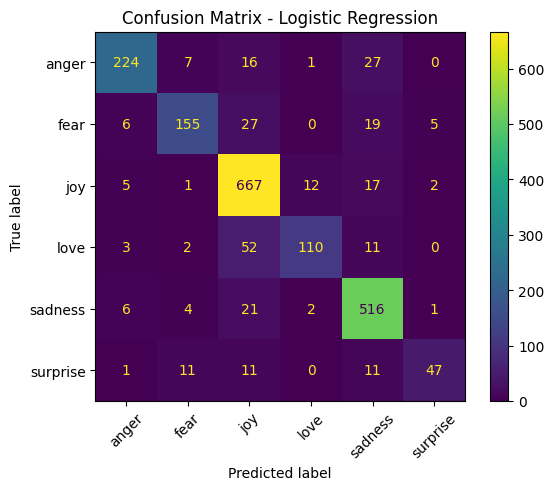

In [11]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_lr, xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Naive Bayes

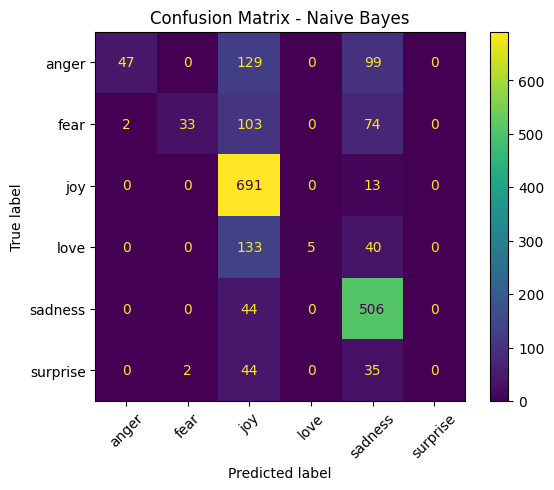

In [12]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_nb, xticks_rotation=45)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

### Model Comparison & Insights

Logistic Regression significantly outperformed Naive Bayes in this task.

While Naive Bayes trained much faster, it showed major limitations in handling this dataset. The confusion matrix reveals that the model collapsed into predicting only a few dominant classes, mainly "joy" and "sadness", while completely ignoring others such as "surprise".

This behavior can be explained by:

- The strong independence assumption of Naive Bayes
- Sensitivity to class imbalance, as some emotions (e.g., "joy") are more frequent than others such as "surprise" 
- Difficulty capturing semantic nuances between similar emotions
- The use of TF-IDF features, which are not ideal for probabilistic models like Naive Bayes

In contrast, Logistic Regression was able to better separate the classes and handle overlapping vocabulary, resulting in significantly higher accuracy and more balanced predictions.

Overall, this experiment highlights the importance of model choice in NLP tasks, especially when dealing with subtle semantic differences between classes.